K-Means Clustering Pipeline

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial import ConvexHull

In [ ]:
# %% [2] Data Ingestion & Preprocessing
# Loading the dataset and scaling features to ensure equal weight during distance calculation
df = pd.read_csv('Mall_Customers.csv')
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset Loaded: {X.shape[0]} customers, {X.shape[1]} features.")
df.head()

Dataset Loaded: 200 customers, 3 features.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


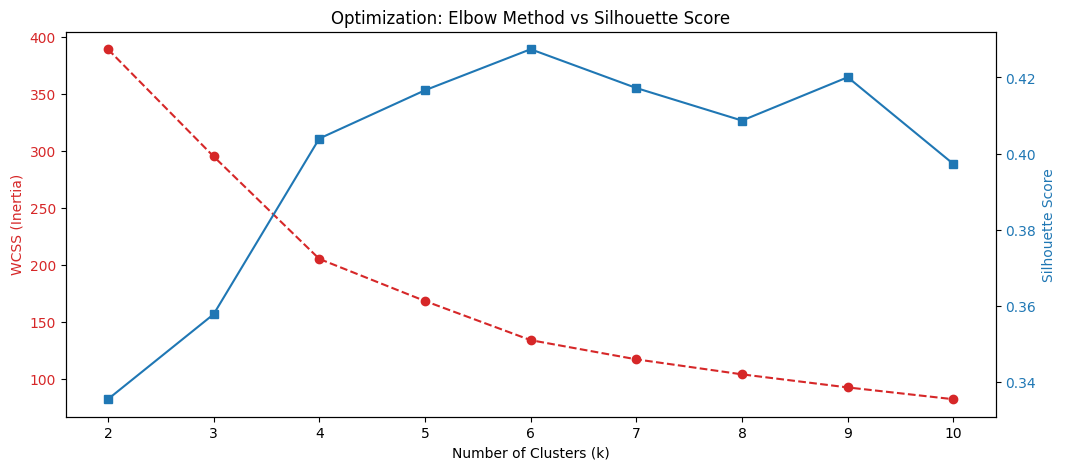

In [ ]:
# %% [3] Hyperparameter Tuning (Elbow & Silhouette)
# We test K values from 2 to 10 to find the 'Sweet Spot'
wcss = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plotting the Multi-Metric Optimization
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot WCSS (Elbow Method)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color='tab:red')
ax1.plot(k_range, wcss, color='tab:red', marker='o', linestyle='--', label='WCSS')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Plot Silhouette Score
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:blue')
ax2.plot(k_range, sil_scores, color='tab:blue', marker='s', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Optimization: Elbow Method vs Silhouette Score')
plt.show()

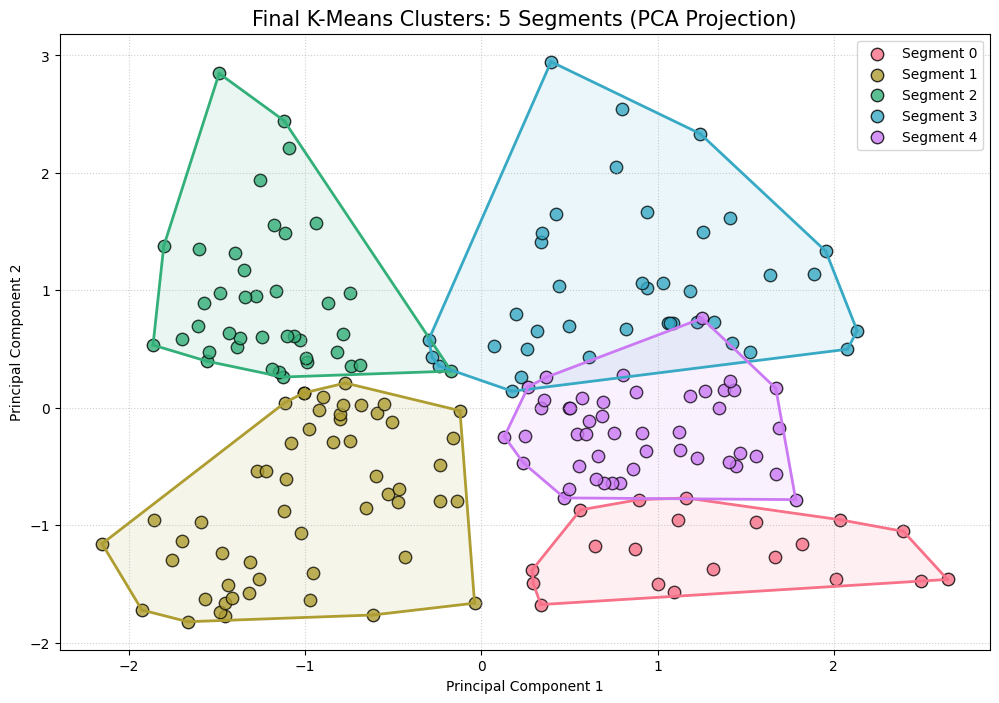

In [ ]:
# %% [4] Final Model & PCA Visualization
# We choose K=5 based on the silhouette peak and elbow bend
best_k = 5
km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=20, random_state=42)
df['KMeans_Labels'] = km_final.fit_predict(X_scaled)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
colors = sns.color_palette('husl', best_k)

for i in range(best_k):
    points = X_pca[df['KMeans_Labels'] == i]
    plt.scatter(points[:, 0], points[:, 1], s=80, color=colors[i],
                label=f'Segment {i}', edgecolors='black', alpha=0.8)

    # Calculate Convex Hull for cluster boundaries
    if len(points) > 2:
        hull = ConvexHull(points)
        for simplex in hull.simplices:
            plt.plot(points[simplex, 0], points[simplex, 1], color=colors[i], lw=2)
        plt.fill(points[hull.vertices, 0], points[hull.vertices, 1], color=colors[i], alpha=0.1)

plt.title(f'Final K-Means Clusters: {best_k} Segments (PCA Projection)', fontsize=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()